# Procesamiento de lenguaje natural
## LSTM Bot QA

### 1 - Datos
El objecto es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [2]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [101]:
import re

import numpy as np
import json

from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.src.utils import to_categorical, plot_model
import logging
import os
from pathlib import Path
import pickle
from keras.models import Model
from keras.layers import Input, LSTM, Dense


In [11]:
with open("datasets/data_volunteers.json") as f:
    data = json.load(f)
    print(f"dataset cargado, campos: {data[0].keys()}")

dataset cargado, campos: dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])


Limpiaremos el dataset de caracteres y abreviaturas. Además acondicionaremos la entrada al encoder y al decoder así como también la salida de este último. Para la entrada del decoder agregaremos un caracter que indique el comienzo de un mensaje (<sos>), para la salida agregaremos uno que indique el fín (<eos>). De esta forma el modelo aprenderá a cortar oraciones.

In [31]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 10

def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):

        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in.split()) >= max_len or len(chat_out.split()) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print(f"Cantidad de rows utilizadas: {len(input_sentences)} \n")
print(f"encoder_input: {input_sentences[1]}")
print(f"decoder_training_input: {output_sentences_inputs[1]}")
print(f"decoder_training_output: {output_sentences[1]}")


Cantidad de rows utilizadas: 9092 

encoder_input: hi how are you 
decoder_training_input: <sos> not bad and you 
decoder_training_output: not bad and you  <eos>


### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [204]:
# Definir el tamaño máximo del vocabulario
MAX_VOCAB_SIZE = 8000

In [58]:
print("INPUT")

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

print("\nOUTPUT")

output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
output_tokenizer.fit_on_texts(output_sentences + output_sentences_inputs)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
output_output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

num_words_output = len(word2idx_outputs) + 1
max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de entrada más larga:", max_out_len)

INPUT
Palabras en el vocabulario: 2724
Sentencia de entrada más larga: 9

OUTPUT
Palabras en el vocabulario: 2732
Sentencia de entrada más larga: 10


In [63]:
print("ENCODER INPUT")
encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print(f"encoder_input_sequences.shape: {encoder_input_sequences.shape}")
print(f"message: {input_sentences[1]}")
print(f"luego de tokenizarla y hacerle padding: {encoder_input_sequences[1]}")

print("\nDECODER INPUT")
decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print(f"decoder_input_sequences.shape: {decoder_input_sequences.shape}")
print(f"message: {output_sentences_inputs[1]}")
print(f"luego de tokenizarla y hacerle padding: {decoder_input_sequences[1]}")

print("\nDECODER OUTPUT")
decoder_output_sequences = pad_sequences(output_output_integer_seq, maxlen=max_out_len, padding='post')
print(f"decoder_output_sequences.shape: {decoder_output_sequences.shape}")
print(f"message: {output_sentences[1]}")
print(f"luego de tokenizarla y hacerle padding: {decoder_output_sequences[1]}")

ENCODER INPUT
encoder_input_sequences.shape: (9092, 9)
message: hi how are you 
luego de tokenizarla y hacerle padding: [ 0  0  0  0  0 16 11  7  2]

DECODER INPUT
decoder_input_sequences.shape: (9092, 10)
message: <sos> not bad and you 
luego de tokenizarla y hacerle padding: [  2  26 240  32   4   0   0   0   0   0]

DECODER OUTPUT
decoder_output_sequences.shape: (9092, 10)
message: not bad and you  <eos>
luego de tokenizarla y hacerle padding: [ 26 240  32   4   1   0   0   0   0   0]


Crearemos una nueva variable decoder_tagets con la representación de decoder_output_sequences pasadas por OHE. Esto es necesario ya que luego usaremos una capa densa con una función softmax de activación. De esta forma tendremos un vector de 3 dimensiones:

La primer dimensión identifica la cantidad de documentos en el corpus

La segunda es la cantidad de palabras que pueden aparecer en un mensaje de salida del chatbot

La tercera es la cantidad de palabras en el vocabulario de los mensajes de salida. Esta dimensión será un vector de 1 y 0s dónde el 1 estará en la columna que identifica la palabra 

In [62]:
decoder_targets = to_categorical(decoder_output_sequences, num_classes=num_words_output)
print(f'decoder_targets.shape: {decoder_targets.shape}')

decoder_targets.shape: (9092, 10, 2733)


### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [71]:
if os.access('./embeddings/cc.en.300.vec', os.F_OK) is False:
    !gunzip -k embeddings/cc.en.300.vec.gz 
else:
    print("El archivo de embeddings ya se encuentra descomprimido")

In [74]:
class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'embeddings/cc.en.300.vec'
    PKL_PATH = 'models/fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [75]:
model_embeddings = FasttextEmbeddings()

In [95]:
from numpy import zeros

words_not_found = []
num_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)
embedding_matrix = zeros((num_words, model_embeddings.N_FEATURES))
for word, index in word2idx_inputs.items():
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector
    else:
        words_not_found.append(word)

print('Cantidad de palabras no procesadas:', len(words_not_found))
print(f'\nembeddings maxtrix shape: {embedding_matrix.shape}')


Cantidad de palabras no procesadas: 0

embeddings maxtrix shape: (2725, 300)


### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

El siguiente modelo tendrá dos capas LSTM encoder+decoder y será el uilizado para entrenamiento

In [123]:
n_units = 128

encoder_inputs = Input(shape=(max_input_len,), name='encoder_input')
encoder_embedding_layer = Embedding(input_dim=num_words, output_dim=model_embeddings.N_FEATURES, weights=[embedding_matrix], trainable=False, name='encoder_input_embedding')
encoder_inputs_x = encoder_embedding_layer(encoder_inputs)
encoder = LSTM(n_units, return_state=True, name='encoder', dropout=0.2)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(max_out_len,), name='decoder_input')
decoder_embedding_layer = Embedding(input_dim=num_words_output, output_dim=n_units, name='decoder_input_embedding')
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, name='decoder', dropout=0.2, recurrent_dropout=0.2)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_output, activation='softmax', name='decoder_softmax_output')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs, name='trainable_model')
model.compile(loss='categorical_crossentropy', optimizer="Adam", metrics=['accuracy'])
model.summary()

Model: "trainable_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_input_embe… │ (None, 9, 300)    │    817,500 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_embe… │ (None, 10, 128)   │    349,824 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (LSTM)      │ [(None, 128),     │    219,648 │ encoder_input_em… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (LSTM)      │ [(None, 10, 128), │    131,584 │ decoder_input_em… │
│                     │ (None, 128),      │            │ encoder[0][1],    │
│                     │ (None, 128)]      │            │ encoder[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_softmax_ou… │ (None, 10, 2733)  │    352,557 │ decoder[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,871,113 (7.14 MB)

 Trainable params: 1,053,613 (4.02 MB)

 Non-trainable params: 817,500 (3.12 MB)

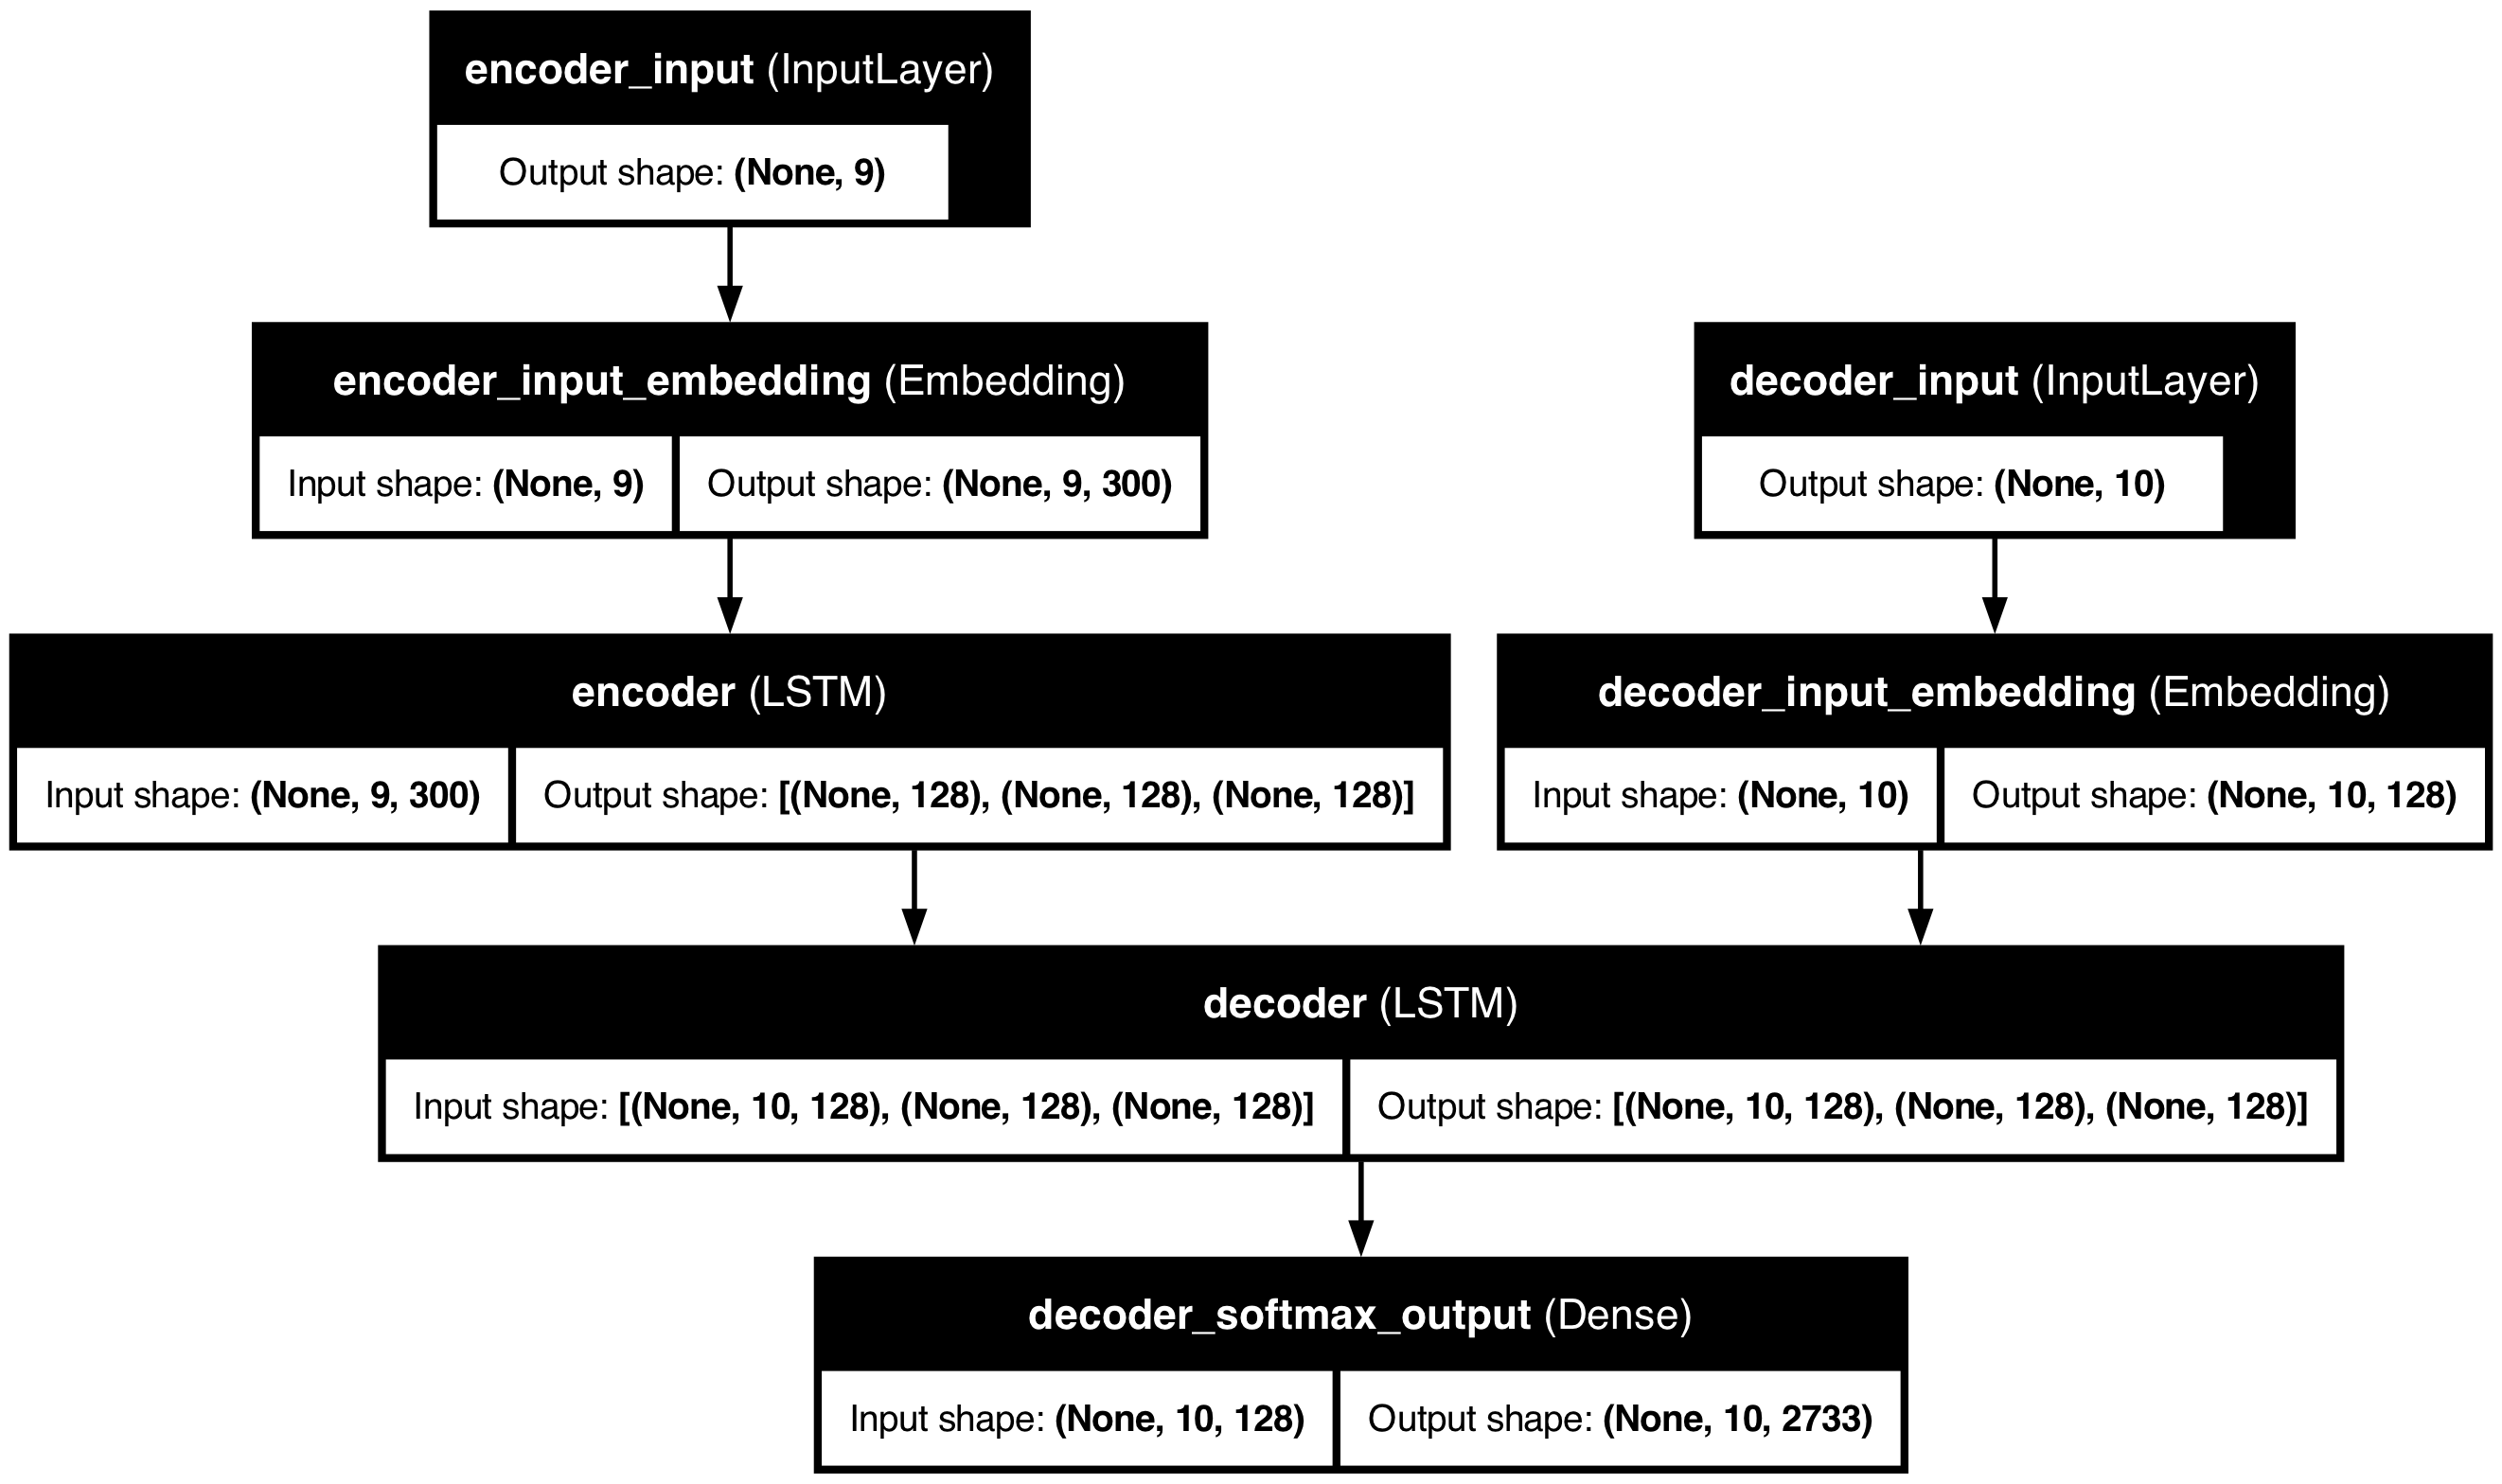

In [124]:
plot_model(model, to_file='img/model_plot.png', show_shapes=True, show_layer_names=True)

Modelo solo de encoder, el mismo servirá para la sección de inferencia

In [125]:
hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.4296 - loss: 4.3729 - val_accuracy: 0.5689 - val_loss: 2.6373
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5648 - loss: 2.5116 - val_accuracy: 0.6124 - val_loss: 2.4206
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.6143 - loss: 2.2111 - val_accuracy: 0.6278 - val_loss: 2.2800
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6342 - loss: 2.0683 - val_accuracy: 0.6441 - val_loss: 2.1788
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6554 - loss: 1.9254 - val_accuracy: 0.6556 - val_loss: 2.1135
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.6664 - loss: 1.8277 - val_accuracy: 0.6592 - val_loss: 2.0737
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.6771 - loss: 1.7312 - val_accuracy: 0.6621 - val_loss: 2.0488
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.6794 - loss: 1.6997 - val_acc

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

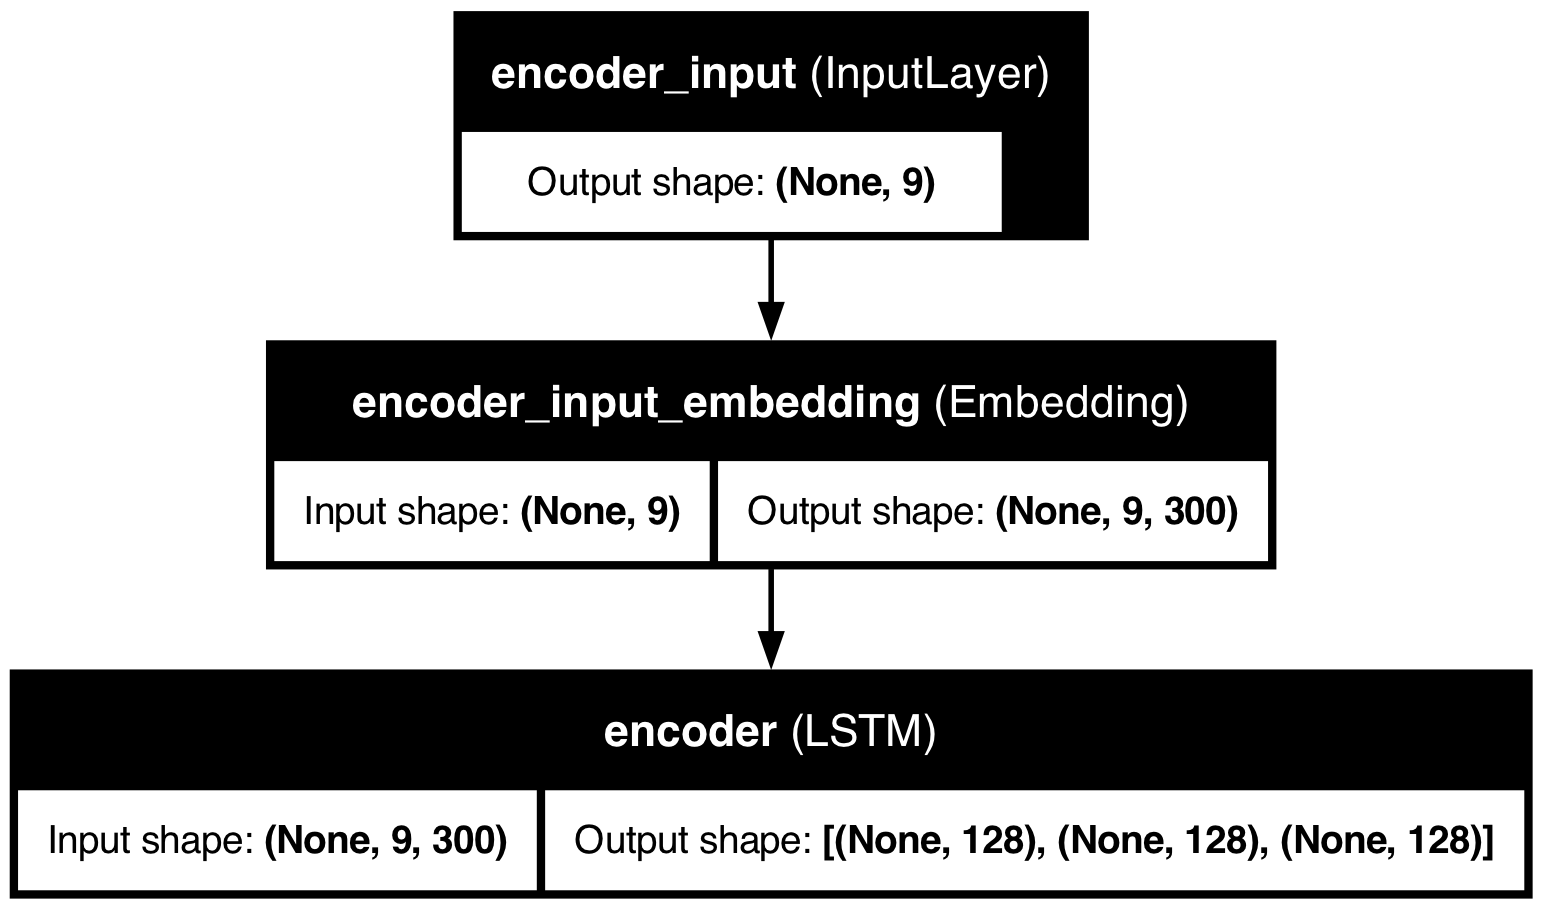

In [139]:
encoder_model = Model(encoder_inputs, encoder_states, name='encoder_model')

plot_model(encoder_model, to_file='img/encoder_plot.png', show_shapes=True, show_layer_names=True)

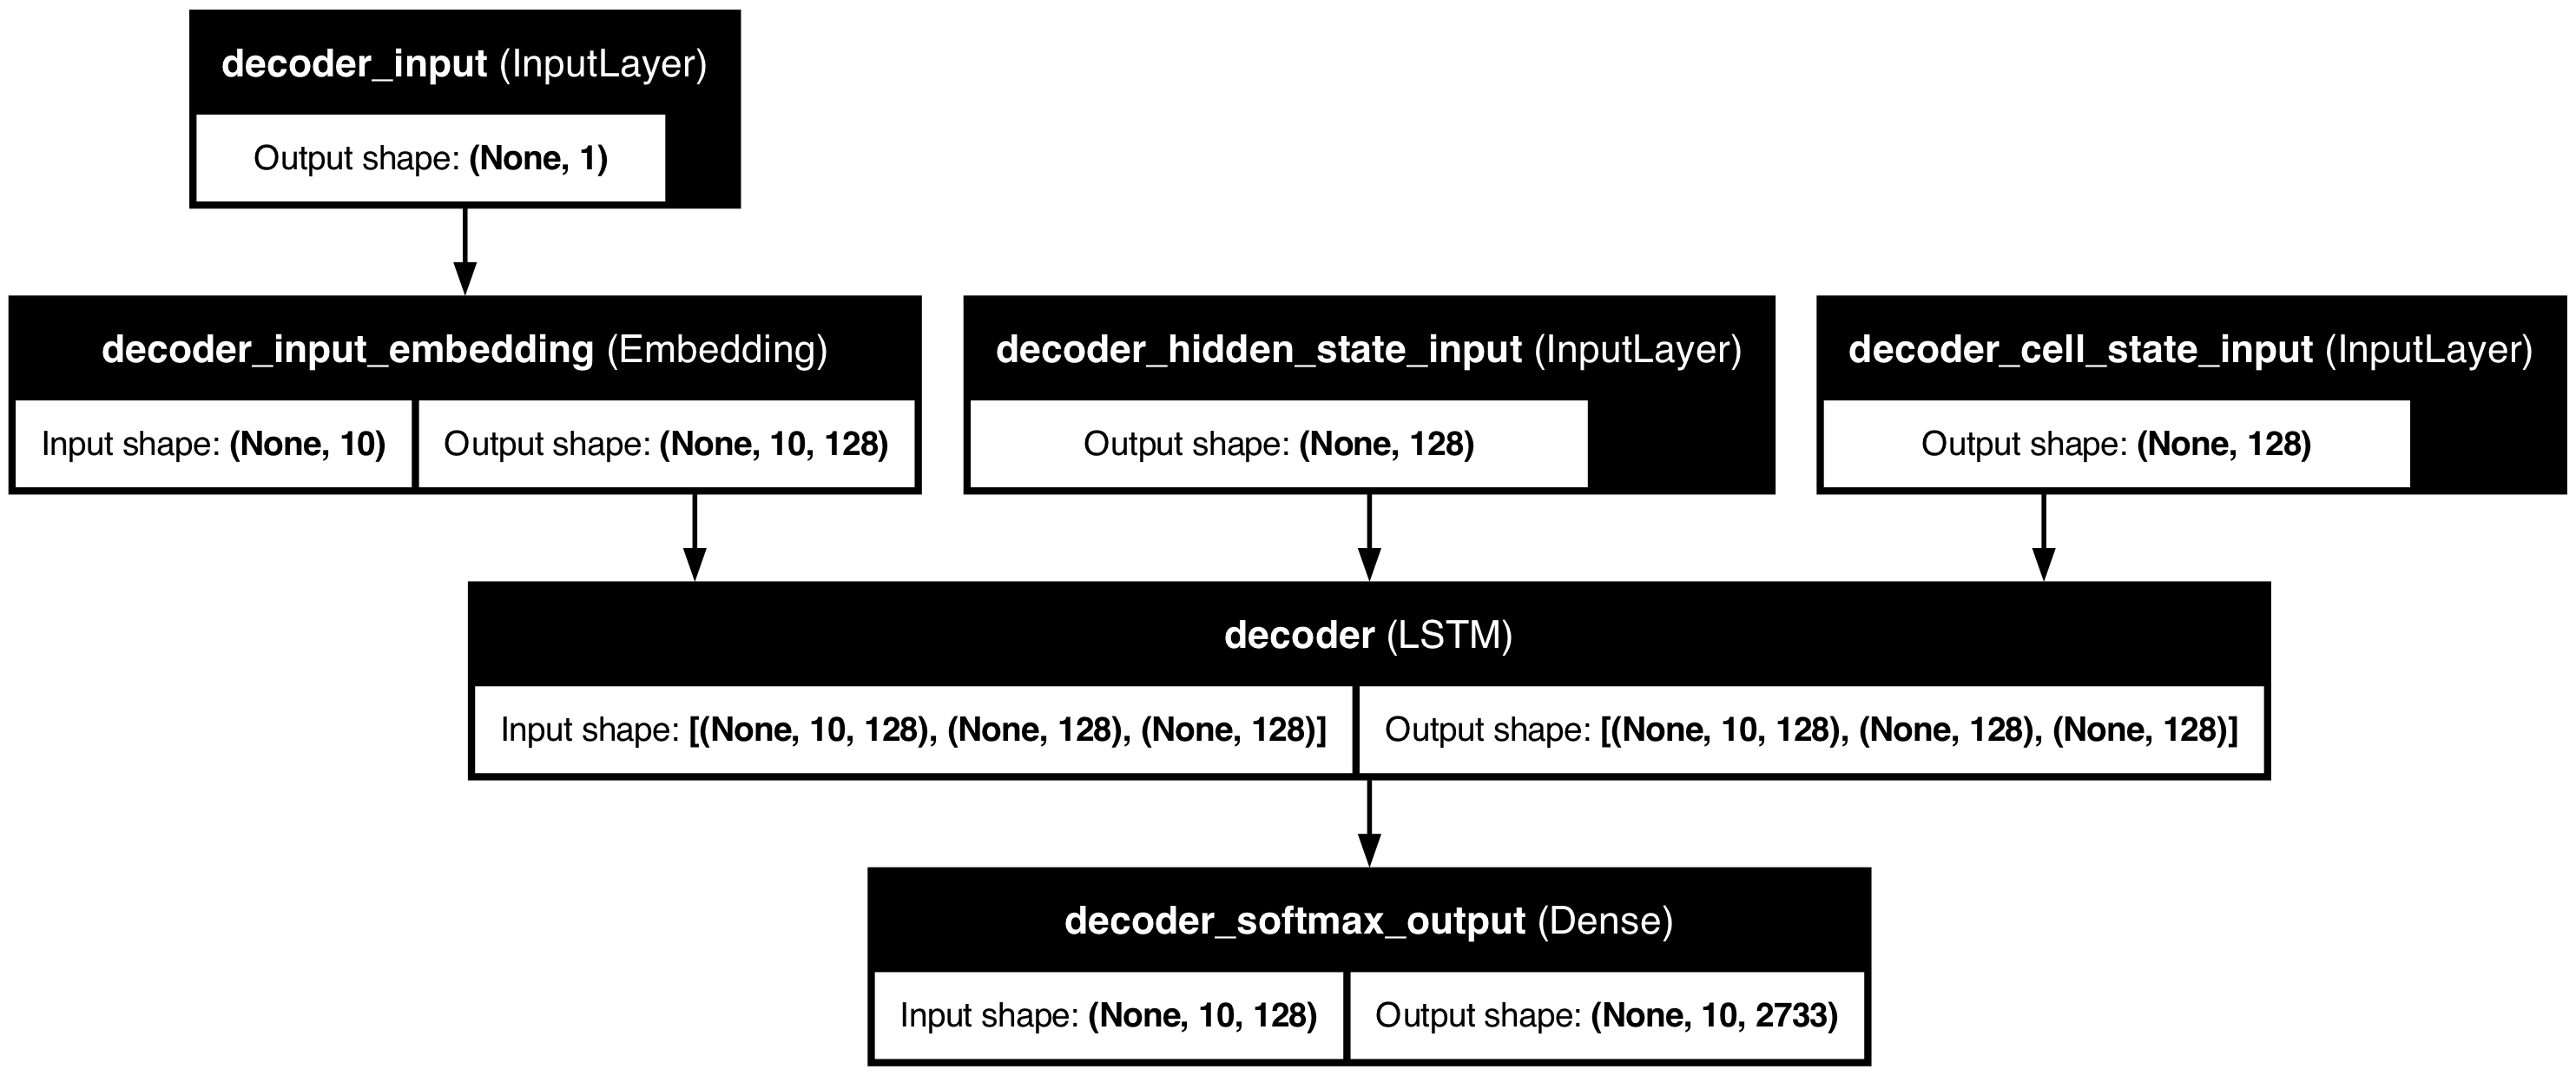

In [142]:
decoder_state_input_h = Input(shape=(n_units,), name='decoder_hidden_state_input')
decoder_state_input_c = Input(shape=(n_units,), name='decoder_cell_state_input')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='decoder_input')
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_single_x, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states, name='decoder_model')

plot_model(decoder_model, to_file='img/decoder_plot.png', show_shapes=True, show_layer_names=True)

In [143]:
# Armar los conversores de índice a palabra:
idx2word_input = {v:k for k, v in word2idx_inputs.items()}
idx2word_target = {v:k for k, v in word2idx_outputs.items()}

In [190]:
def predict(input_seq):
    states_value = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

In [197]:
def answer_to(frase):

    seq = input_tokenizer.texts_to_sequences([frase])
    input_seq = pad_sequences(seq, maxlen=max_input_len)
    
    prediction = predict(input_seq)
    
    print('Input:', frase)
    print('Response:', prediction)

In [206]:
answer_to("hello how are you")
print("\n")
answer_to("do you have any pet?")
print("\n")
answer_to("Where are you from?")
print("\n")
answer_to("What do you do in your spare time?")
print("\n")
answer_to("What do you do?")
print("\n")
answer_to("What is your favorite color?")
print("\n")


Input: hello how are you
Response: i m fine


Input: do you have any pet?
Response: no i don t have any pets


Input: Where are you from?
Response: i am from russia moscow you


Input: What do you do in your spare time?
Response: i don t know


Input: What do you do?
Response: i m a student


Input: What is your favorite color?
Response: i like to go to the beach


